<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/Aula_9_Sistemas_Lineares_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# Redefinindo a matriz do sistema
A = np.array([[3, -0.1, -0.2],
              [0.1, 7, -0.3],
              [0.3, -0.2, 10]])

b = np.array([7.85, -19.3, 71.4])
Epest=100
xk=np.array([1,1, 1])
vnew=[]

<ipython-input-2-164e6746b193>:25: RuntimeWarning: invalid value encountered in scalar divide
  x[i] = (b[i] - soma) / A[i, i]


Conjunto 1 - Dominância Diagonal: False | Convergiu: True
Conjunto 2 - Dominância Diagonal: False | Convergiu: False
Conjunto 3 - Dominância Diagonal: False | Convergiu: False


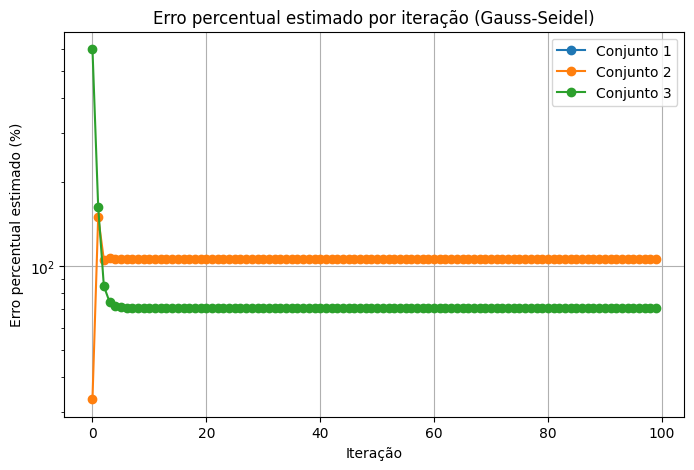

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def check_dominancia(A):
    """Retorna True se A for estritamente diagonal dominante por linhas."""
    n = A.shape[0]
    for i in range(n):
        if abs(A[i, i]) <= np.sum(np.abs(A[i, :])) - abs(A[i, i]):
            return False
    return True

def gauss_seidel(A, b, x0=None, tol=1e-6, max_iter=100):
    """Resolve Ax = b por Gauss-Seidel. Retorna x, lista de erros e convergiu (bool)."""
    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()

    erros = []
    for k in range(1, max_iter+1):
        x_old = x.copy()
        for i in range(n):
            soma = np.dot(A[i, :i], x[:i]) + np.dot(A[i, i+1:], x_old[i+1:])
            x[i] = (b[i] - soma) / A[i, i]

        # Calcula erro percentual estimado máximo (com tratamento de divisão por zero)
        dif = np.abs(x - x_old)
        with np.errstate(divide='ignore', invalid='ignore'):
            erro = np.nanmax(np.where(np.abs(x) > 1e-14, dif / np.abs(x), 0)) * 100
        erros.append(erro)

        if erro < tol:
            return x, erros, True

    return x, erros, False

def plota_erro(erros, label):
    plt.semilogy(erros, marker='o', label=label)
    plt.xlabel('Iteração')
    plt.ylabel('Erro percentual estimado (%)')
    plt.grid(True)
    plt.legend()

# ================================
# CONFIGURAÇÕES GERAIS
x0 = np.array([1.0, 1.0, 1.0])
tol = 0.5 * 10**(2 - 6)  # 0.005%

# ================================
# CONJUNTO 1
A1 = np.array([[8, 3, 1],
               [-6, 0, 7],
               [2, 4, -1]], dtype=float)
b1 = np.array([12, 1, 5], dtype=float)
x1, erros1, conv1 = gauss_seidel(A1, b1, x0, tol)
print("Conjunto 1 - Dominância Diagonal:", check_dominancia(A1), "| Convergiu:", conv1)

# ================================
# CONJUNTO 2
A2 = np.array([[1, 1, 5],
               [-1, 4, -1],
               [3, 1, -1]], dtype=float)
b2 = np.array([7, 4, 3], dtype=float)
x2, erros2, conv2 = gauss_seidel(A2, b2, x0, tol)
print("Conjunto 2 - Dominância Diagonal:", check_dominancia(A2), "| Convergiu:", conv2)

# ================================
# CONJUNTO 3
A3 = np.array([[-7, 3, 5],
               [-2, 4, -5],
               [0, 2, -1]], dtype=float)
b3 = np.array([7, -3, 1], dtype=float)
x3, erros3, conv3 = gauss_seidel(A3, b3, x0, tol)
print("Conjunto 3 - Dominância Diagonal:", check_dominancia(A3), "| Convergiu:", conv3)

# ================================
# PLOT
plt.figure(figsize=(8, 5))
plota_erro(erros1, "Conjunto 1")
plota_erro(erros2, "Conjunto 2")
plota_erro(erros3, "Conjunto 3")
plt.title("Erro percentual estimado por iteração (Gauss-Seidel)")
plt.show()



Conjunto 1: Diag. Dominante? False
Convergiu? False


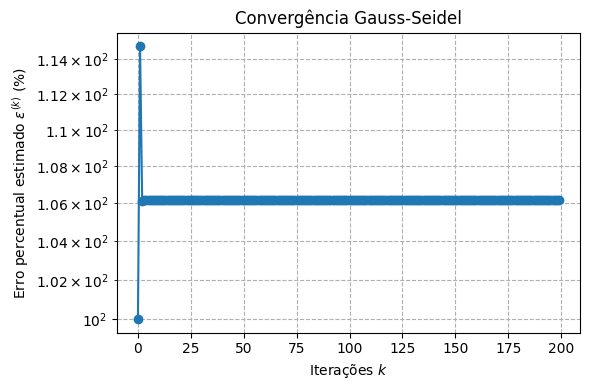

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def check_dominancia(A):
    """Retorna True se A for estritamente diagonal dominante por linhas."""
    n = A.shape[0]
    for i in range(n):
        if abs(A[i, i]) <= np.sum(np.abs(A[i, :])) - abs(A[i, i]):
            return False
    return True

def gauss_seidel(A, b, x0=None, tol=1e-6, max_iter=200):
    """
    Resolve Ax = b por Gauss-Seidel.
    Retorna (x, erros_percentuais, convergiu_bool).
    """
    n = A.shape[0]
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()

    erros = []
    for k in range(1, max_iter + 1):
        x_old = x.copy()
        for i in range(n):
            soma = np.dot(A[i, :i], x[:i]) + np.dot(A[i, i+1:], x_old[i+1:])
            x[i] = (b[i] - soma) / A[i, i]

        # Calcula erro percentual máximo
        dif = np.abs(x - x_old)
        with np.errstate(divide='ignore', invalid='ignore'):
            erro = np.nanmax(np.where(np.abs(x) > 1e-14, dif / np.abs(x), 0)) * 100
        erros.append(erro)

        if erro < tol:
            return x, erros, True

    return x, erros, False

def plota_erro(erros):
    plt.figure(figsize=(6, 4))
    plt.semilogy(erros, marker='o')
    plt.xlabel('Iterações $k$')
    plt.ylabel('Erro percentual estimado $\\varepsilon^{(k)}$ (%)')
    plt.grid(True, which='both', ls='--')
    plt.title("Convergência Gauss-Seidel")
    plt.tight_layout()
    plt.show()

# =============================
# Exemplo de uso para o Conjunto 1
A1 = np.array([[1, 1, 5],
               [-1, 4, -1],
               [3, 1, -1]],float)

b1 = np.array([7, 4, 3],float)

print("Conjunto 1: Diag. Dominante?", check_dominancia(A1))
x1, erros1, conv1 = gauss_seidel(A1, b1, tol=1e-6)
print("Convergiu?", conv1)
plota_erro(erros1)
